<a href="https://colab.research.google.com/github/waleonr/Hidroinformatica26/blob/main/NOAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyarrow

In [ ]:
# Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ftplib
import pandas as pd
import io
import os

In [ ]:
import ftplib

ftp = ftplib.FTP("ftp.ncei.noaa.gov")
ftp.login()

# directorio del estado "01"
state_dir = "pub/data/15min_precip-3260/01"
ftp.cwd(state_dir)

files = ftp.nlst()
print("Archivos en 01:", files)

ftp.quit()

Archivos en 01: ['3260_01_1971-1998.tar.Z', '3260_01_1999-1999.tar.Z', '3260_01_2000-2000.tar.Z', '3260_01_2001-2001.tar.Z', '3260_01_2002-2002.tar.Z', '3260_01_2003-2003.tar.Z', '3260_01_2004-2004.tar.Z', '3260_01_2005-2005.tar.Z', '3260_01_2006-2006.tar.Z', '3260_01_2007-2007.tar.Z', '3260_01_2008-2008.tar.Z', '3260_01_2009-2009.tar.Z', '3260_01_2010-2010.tar.Z', '3260_01_2011-2011.tar.Z']


'221 Goodbye.'

In [ ]:
import ftplib
import os

FTP_SERVER = "ftp.ncei.noaa.gov"
REMOTE_DIR = "pub/data/15min_precip-3260/01"
LOCAL_DIR = "/content/noaa_15min_01"

os.makedirs(LOCAL_DIR, exist_ok=True)

ftp = ftplib.FTP(FTP_SERVER)
ftp.login()
ftp.cwd(REMOTE_DIR)

files = ftp.nlst()

for fname in files:
    local_path = os.path.join(LOCAL_DIR, fname)
    if not os.path.exists(local_path):
        print("Descargando:", fname)
        with open(local_path, "wb") as f:
            ftp.retrbinary(f"RETR {fname}", f.write)

ftp.quit()

'221 Goodbye.'

In [ ]:
from datetime import datetime, timedelta
import pandas as pd
import re

def parse_qpcpht_line(line):

    if "QPCPHT" not in line:
        return None

    tokens = line.strip().split()
    header = tokens[0]

    # ---- ID estación ----
    station_id = header[3:9]

    # ---- Fecha base (solo año y mes) ----
    try:
        year  = int(header[17:21])
        month = int(header[21:23])
        base_date = datetime(year, month, 1)
    except:
        return None

    records = []
    i = 1

    while i < len(tokens) - 1:
        hhmm_raw = tokens[i]
        val_raw  = tokens[i + 1]

        hhmm = re.sub(r"\D", "", hhmm_raw)
        val  = re.sub(r"\D", "", val_raw)

        if hhmm == "" or val == "":
            i += 1
            continue

        try:
            hhmm = int(hhmm)
            val  = int(val)
        except:
            i += 2
            continue

        # ---- valores faltantes NOAA ----
        if val == 99999:
            i += 2
            continue

        # ---- manejo seguro de tiempo ----
        if hhmm == 2500:
          i += 2
          continue

        else:
            hour = hhmm // 100
            minute = hhmm % 100

            # ❗ FILTRO CRÍTICO
            if hour > 23 or minute > 59:
                i += 2
                continue

            ts = base_date + timedelta(hours=hour, minutes=minute)

        records.append({
            "station_id": station_id,
            "fecha_hora": ts,
            "precip_mm": val / 100.0
        })

        i += 2

    if records:
        return pd.DataFrame(records)

    return None


In [ ]:
import glob

import glob
import os

data_files = [
    f for f in glob.glob("/content/noaa_15min_01/*")
    if os.path.isfile(f)
    and f.split("/")[-1].startswith("3260_")
    and ".tar" not in f
]

print("Archivos de datos:", len(data_files))
data_files[:5]

Archivos de datos: 462


['/content/noaa_15min_01/3260_018670_2010-2010',
 '/content/noaa_15min_01/3260_013620_2005-2005',
 '/content/noaa_15min_01/3260_012675_2000-2000',
 '/content/noaa_15min_01/3260_014193_2009-2009',
 '/content/noaa_15min_01/3260_010369_2006-2006']

In [ ]:
dfs = []

for file in data_files:
    print("Procesando:", file)
    with open(file, "r", errors="ignore") as f:
        for line in f:
            df = parse_qpcpht_line(line)
            if df is not None:
                dfs.append(df)

print("Bloques válidos:", len(dfs))


Procesando: /content/noaa_15min_01/3260_018670_2010-2010
Procesando: /content/noaa_15min_01/3260_013620_2005-2005
Procesando: /content/noaa_15min_01/3260_012675_2000-2000
Procesando: /content/noaa_15min_01/3260_014193_2009-2009
Procesando: /content/noaa_15min_01/3260_010369_2006-2006
Procesando: /content/noaa_15min_01/3260_015553_2004-2004
Procesando: /content/noaa_15min_01/3260_010831_2009-2009
Procesando: /content/noaa_15min_01/3260_018517_por-1998
Procesando: /content/noaa_15min_01/3260_012675_2009-2009
Procesando: /content/noaa_15min_01/3260_012124_1999-1999
Procesando: /content/noaa_15min_01/3260_013655_2002-2002
Procesando: /content/noaa_15min_01/3260_010748_2008-2008
Procesando: /content/noaa_15min_01/3260_018673_2006-2006
Procesando: /content/noaa_15min_01/3260_014193_2002-2002
Procesando: /content/noaa_15min_01/3260_015397_2000-2000
Procesando: /content/noaa_15min_01/3260_013043_2004-2004
Procesando: /content/noaa_15min_01/3260_018517_2002-2002
Procesando: /content/noaa_15min_

In [ ]:
df_precip = pd.concat(dfs, ignore_index=True)

print("Registros totales:", len(df_precip))
df_precip.head()

Registros totales: 387478


,station_id,fecha_hora,precip_mm
0,018670,2010-01-01 00:10:00,19.45
1,018670,2010-01-01 00:10:00,22.00
2,018670,2010-01-01 00:10:00,23.00
3,018670,2010-01-01 00:10:00,25.00
4,018670,2010-01-01 00:10:00,6.45


In [ ]:
df_precip["station_id"].nunique()

39

In [ ]:
df_precip["fecha_hora"].min(), df_precip["fecha_hora"].max()

(Timestamp('1971-05-01 00:00:00'), Timestamp('2011-11-01 00:50:00'))

In [ ]:
df_precip.describe()

,fecha_hora,precip_mm
count,387478,387478.000000
mean,1991-11-28 02:40:58.388347136,15.714257
min,1971-05-01 00:00:00,0.300000
25%,1983-01-01 00:10:00,9.150000
50%,1991-12-01 00:10:00,16.300000
75%,2000-11-01 00:20:00,24.000000
max,2011-11-01 00:50:00,25.000000
std,NaN,7.761651


In [ ]:
station_counts = (
    df_precip
    .groupby("station_id")
    .size()
    .sort_values(ascending=False)
)

station_counts.head()

,0
station_id,
010140,15647
018178,15302
018209,14322
013519,13848
010369,13537


In [ ]:
top_station_id = station_counts.index[0]
top_station_id

'010140'

In [ ]:
df_top_station = df_precip[df_precip["station_id"] == top_station_id].copy()

print("Estación seleccionada:", top_station_id)
print("Número de registros:", len(df_top_station))

Estación seleccionada: 010140
Número de registros: 15647


In [ ]:
df_top_station["fecha_hora"].min(), df_top_station["fecha_hora"].max()

(Timestamp('1971-05-01 00:00:00'), Timestamp('2011-11-01 00:50:00'))

In [ ]:
df = df_top_station.copy()

df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])
df = df.sort_values("fecha_hora")

In [ ]:
df = (
    df.groupby("fecha_hora", as_index=False)
      .agg({
          "precip_mm": "sum",
          "station_id": "first"
      })
)

In [ ]:
full_time_index = pd.date_range(
    start=df["fecha_hora"].min(),
    end=df["fecha_hora"].max(),
    freq="15min"
)

In [ ]:
df_full = (
    df.set_index("fecha_hora")
      .reindex(full_time_index)
)

df_full["precip_mm"] = df_full["precip_mm"].fillna(0.0)
df_full["station_id"] = df["station_id"].iloc[0]
df_full = df_full.reset_index().rename(columns={"index": "fecha_hora"})

In [ ]:
(df_full["precip_mm"] == 0).sum()

np.int64(1419466)

In [ ]:
df_full["precip_mm"].describe()

,precip_mm
count,1.420228e+06
mean,1.350114e-02
std,6.995896e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.452000e+02


<Axes: xlabel='fecha_hora'>

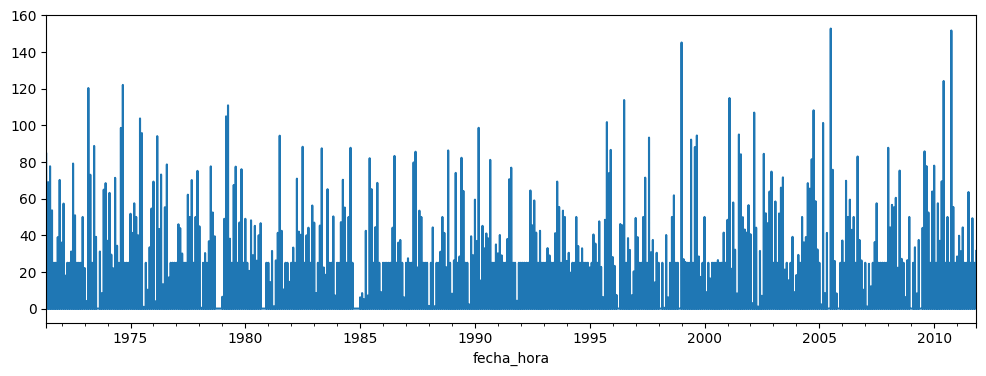

In [ ]:
df_full.set_index("fecha_hora")["precip_mm"].resample("D").sum().plot(figsize=(12,4))

In [ ]:
df_full[df_full["precip_mm"] > 80].shape

(11, 3)

In [ ]:
df_full = df_full.sort_index()
df_full["fecha_hora"] = pd.to_datetime(df_full["fecha_hora"])

In [ ]:
df_full = df_full.set_index("fecha_hora").sort_index()

In [ ]:
inicio = "2011-07-15"
fin    = "2011-08-20"

df_intervalo = df_full.loc[inicio:fin, "precip_mm"]

<Axes: xlabel='fecha_hora'>

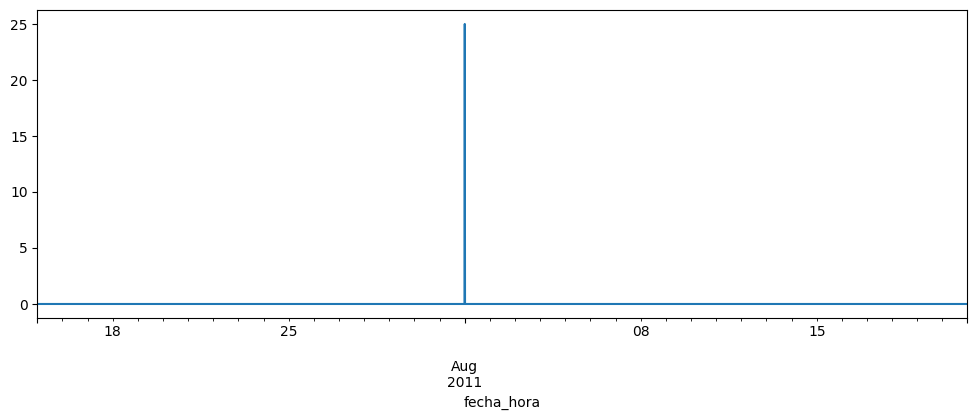

In [ ]:
df_intervalo.plot(figsize=(12,4))

In [ ]:
df_full.to_csv(
    "precip_15min_full.csv",
    index=True,
    date_format="%Y-%m-%d %H:%M:%S"
)